In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from scipy.spatial import ConvexHull, QhullError
import seaborn as sns
from geopy import distance, Point
from tqdm import tqdm

# Title


## Introduction

## Data Exploration

Before processing, feature engineering and modeling the data it is crucial to get a throrough understanding of the datasets structure. 

## Defining necessary functions

In [2]:
# Function for Kaggle submission
def submit(test_ids, ylong, ylat):
    submission = pd.DataFrame({
        'ID': test_ids,  # Pass the test ID column
        'longitude_predicted': ylong,  # Your predicted longitudes
        'latitude_predicted': ylat    # Your predicted latitudes
    })

    submission = submission[['ID', 'longitude_predicted', 'latitude_predicted']].sort_values(by = 'ID').reset_index(drop=True)

    i = 1
    while os.path.exists(f'submission_{i}.csv'): # This ensures no file is overwritten
        i += 1

    filename = f'submission_{i}.csv'
    submission.to_csv(filename, index=False)
    print(f"Results saved to {filename}")

# Function for calcualting the convex hull area for each vessel
def calculate_convex_hull_area(df):
    results = []
    
    # Grouping by vessel data and then iterating through all vessels
    for vessel_id, vessel_data in df.groupby('vesselId'):
        # Ensuring at least three unique points exist.
        unique_points = vessel_data[['latitude', 'longitude']].drop_duplicates()
        if len(unique_points) < 3:
            results.append({'vesselId': vessel_id, 'covered_area': 0})
            continue

        lat_to_m = 111320  # meters per degree latitude
        long_to_m = 40075000 * np.cos(np.radians(vessel_data['latitude'].mean())) / 360  # meters per degree longitude
        
        # Creating points for ConvexHull conversion
        points = np.column_stack((unique_points['longitude'] * long_to_m, unique_points['latitude'] * lat_to_m))
        
        # Calculating the convex hull area. NOTE: if ConvexHull fails; area is set to 0
        try:
            hull = ConvexHull(points)
            area = hull.area
        except QhullError:
            area = 0

        results.append({'vesselId': vessel_id, 'covered_area': area})
    
    return pd.DataFrame(results)

# Function for calculating the haversine distance between two points
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371000 # Mean Earth radius in meters
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1) # Degrees --> radians
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2) # Degrees --> radians

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

# Function for calculating the average deviation in position
def average_distance_in_meters(y_true_lat, y_true_long, y_pred_lat, y_pred_long):
    distances = haversine_distance(y_true_lat, y_true_long, y_pred_lat, y_pred_long)
    avg_distance = np.mean(distances)
    return avg_distance

# Function for calculating the estimated target position based on historical data
def estimate_position(lat, long, cog, sog, time_diff):
    cog_rad = np.deg2rad(cog)
    distance_m = sog * 0.514444 * time_diff
    origin = Point(lat, long)
    target = distance.distance(meters = distance_m).desination(origin, cog_rad)
    target_lat, target_long = target.latitude, target.longitude
    return target_lat, target_long

# Function for calculated an estimated position based on historical data
def estimate_position(lat, long, cog, sog, time_diff):
    cog_rad = np.deg2rad(cog)
    distance_m = sog * 0.514444 * time_diff
    origin = Point(lat, long)
    target = distance.distance(meters = distance_m).desination(origin, cog_rad)
    target_lat, target_long = target.latitude, target.longitude
    return target_lat, target_long

# Function for calculating the change in position
def delta_position(row):
    earth_radius = 6371000 # Mean Earth radius in meters
    cog_rad = np.deg2rad(row['last_cog']) # Degrees --> radians
    estimated_delta_lat = (row['estimated_distance'] * np.cos(cog_rad)) / earth_radius
    estimated_delta_long = (row['estimated_distance'] * np.sin(cog_rad)) / (earth_radius * np.cos(np.deg2rad(row['last_lat'])))
    
    return np.rad2deg(estimated_delta_lat), np.rad2deg(estimated_delta_long)

# Function for creating the first window
def initial_window(row):
    row['last_lat'] = row['latitude']
    row['last_long'] = row['longitude']
    row['last_sog'] = row['sog']
    row['last_cog'] = row['cog']
    row['last_heading'] = row['heading']
    row['last_is_moving'] = row['is_moving']
    # NOTE: the three below features are set to 0 for the first window only.
    row['time_diff'] = 0
    row['estimated_distance'] = 0
    row['estimated_delta_lat'] = 0
    row['estimated_delta_long'] = 0
    
    return row

# Function for retrieving the last known values
def get_last_known_values(train_df):
    # Sort data by 'vesselId' and 'time' to ensure chronological order
    train_df = train_df.sort_values(by=['vesselId', 'time']).reset_index(drop=True)

    # Get the last known values for each vessel
    last_known_values = train_df.groupby('vesselId').last().reset_index()

    # Select only the relevant columns to carry forward to the test set
    columns_to_keep = ['vesselId', 'latitude', 'longitude', 'port_lat', 'port_long', 
                       'cog', 'sog', 'heading', 'is_moving', 'time']
    last_known_values = last_known_values[columns_to_keep]

    return last_known_values

In [3]:
# First we read the necessary csv files. NOTE: Different delimiter for some files.
df_train = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/ais_train.csv', delimiter = '|')
df_test = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/ais_test.csv')
df_vessels = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/vessels.csv', delimiter = '|')
df_schedules = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/schedules_to_may_2024.csv', delimiter = '|')
df_ports = pd.read_csv('/Users/jakobrudeovstaas/Desktop/ML/ports.csv', delimiter = '|')
# Train and test is sorted by vessel ID and time. Time is converted to datetime
df_train = df_train.sort_values(by = ['vesselId', 'time'])
df_test = df_test.sort_values(by = ['vesselId', 'time'])
df_train['time'] = pd.to_datetime(df_train['time'])
df_test['time'] = pd.to_datetime(df_test['time'])

# Filling NaNs with backward fill
df_train['portId'] = df_train['portId'].transform(lambda x: x.bfill())

# Using navstat to determine if vessel is moving or not
df_train['is_moving'] = df_train['navstat'].apply(lambda navstat: 1 if navstat == 0 or navstat == 8 else 0)

# Renaming port data and then merging with df_train
df_ports = df_ports.rename(columns = {'latitude': 'port_lat', 'longitude': 'port_long'})
df_train = df_train.merge(df_ports[['portId', 'port_lat', 'port_long']], on = 'portId', how = 'left')

# Merging some vessel specific data
df_train = df_train.merge(df_vessels[['vesselId', 'length', 'GT']], on = 'vesselId', how = 'left')
df_test = df_test.merge(df_vessels[['vesselId', 'length', 'GT']], on = 'vesselId', how = 'left')

# Encoding vessel ID
label_encoder = LabelEncoder()
df_train['vesselId_encoded'] = label_encoder.fit_transform(df_train['vesselId'])
df_test['vesselId_encoded'] = label_encoder.transform(df_test['vesselId'])

## Train set processing

In [4]:
def create_train(df, windowSize):
    # NOTE: this function requires df to be sorted by vessel ID and time.
    # Initializing an empty array for the data
    data = []
    # Finding all unique vessels
    vessels = df['vesselId'].unique()

    # Using tqdm for progress bar (for-loop can run slow on large dataset)
    for vessel in tqdm(vessels):
        # Finding all data for one unique vessel
        vessel_data = df[df['vesselId'] == vessel].sort_values(by='time')
        # Calculating the ConvexHull area for each vessel
        area_df = calculate_convex_hull_area(vessel_data)
        if not area_df.empty and 'covered_area' in area_df.columns:
            total_area = calculate_convex_hull_area(vessel_data)['covered_area'].values[0]
        else:
             total_area = 0
        # Initializing empty array for the internal data and the last row
        data_internal = [] 
        last_row = None
        i = 0

        while not vessel_data.empty:
            first_window_time = vessel_data['time'].min() # Initial time within window
            end_window_date = (first_window_time + pd.Timedelta(days = windowSize)).replace(hour = 23, minute = 59, second = 59)
            # Gathering the data within the specified window size
            window_rows = vessel_data[(vessel_data['time'] >= first_window_time) & (vessel_data['time'] <= end_window_date)].copy()

            if i == 0 and last_row is None: # This sets the first window
                window_rows = initial_window(window_rows)
            else: # This applies to all consecutive windows after initial window
                    window_rows['last_lat'] = last_row['latitude']
                    window_rows['last_long'] = last_row['longitude']
                    window_rows['last_port_lat'] = last_row['port_lat']
                    window_rows['last_port_long'] = last_row['port_long']
                    window_rows['last_sog'] = last_row['sog']
                    window_rows['last_cog'] = last_row['cog']
                    window_rows['last_heading'] = last_row['heading']
                    window_rows['last_is_moving'] = last_row['is_moving']
                    window_rows['time_diff'] = (window_rows['time'] - last_row['time']).dt.total_seconds()
                    window_rows['estimated_distance'] = window_rows['last_sog'] * window_rows['time_diff'] # in meters
                    deltas = window_rows.apply(lambda row: delta_position(row), axis = 1)
                    window_rows['estimated_delta_lat'], window_rows['estimated_delta_long'] = zip(*deltas)
            
            # Adding encoded vessel ID
            window_rows['vesselId_encoded'] = window_rows['vesselId_encoded']
            # Adding vessel specific data
            window_rows['length'] = window_rows['length']
            window_rows['GT'] = window_rows['GT']
            # Adding some trigonometric features
            window_rows['last_heading_sin'] = np.sin(np.deg2rad(window_rows['last_heading']))
            window_rows['last_heading_cos'] = np.cos(np.deg2rad(window_rows['last_heading']))
            # Adding horizontal and vertical expected displacement
            #window_rows['displacement_hor'] = window_rows['last_sog'] * window_rows['last_cog_cos']
            #window_rows['displacement_vert'] = window_rows['last_sog'] * window_rows['last_cog_sin']
            # Adding total ConvexHull area
            window_rows['total_area'] = total_area

            # Adding data and updating last_row
            last_row = window_rows.iloc[-1]
            data_internal.append(window_rows)
            vessel_data = vessel_data.drop(window_rows.index)
            i += 1
        
        vessel_df = pd.concat(data_internal, ignore_index = True)
        data.append(vessel_df)
    
    return pd.concat(data, ignore_index = True)

In [5]:
train_data = create_train(df_train, 2)

100%|██████████| 688/688 [01:28<00:00,  7.78it/s]


In [6]:
train_data.columns

Index(['time', 'cog', 'sog', 'rot', 'heading', 'navstat', 'etaRaw', 'latitude',
       'longitude', 'vesselId', 'portId', 'is_moving', 'port_lat', 'port_long',
       'length', 'GT', 'vesselId_encoded', 'last_lat', 'last_long', 'last_sog',
       'last_cog', 'last_heading', 'last_is_moving', 'time_diff',
       'estimated_distance', 'estimated_delta_lat', 'estimated_delta_long',
       'last_heading_sin', 'last_heading_cos', 'total_area', 'last_port_lat',
       'last_port_long'],
      dtype='object')

In [7]:
# Retrieving the last known values from train set
last_known_train_values = get_last_known_values(df_train)

In [8]:
def create_test(df, lastKnown):
    data = []
    vessels = df['vesselId'].unique()

    last_known_values_dict = lastKnown.set_index('vesselId').to_dict('index')

    for vessel in tqdm(vessels):
        vessel_data = df[df['vesselId'] == vessel].sort_values(by = 'time').reset_index(drop = True)

        if vessel in last_known_values_dict:
            last_known_values = last_known_values_dict[vessel]
        else:
            continue

        vessel_data['last_lat'] = last_known_values['latitude']
        vessel_data['last_long'] = last_known_values['longitude']
        vessel_data['last_port_lat'] = last_known_values['port_lat']
        vessel_data['last_port_long'] = last_known_values['port_long']
        vessel_data['last_cog'] = last_known_values['cog']
        vessel_data['last_heading'] = last_known_values['heading']
        vessel_data['last_sog'] = last_known_values['sog']
        vessel_data['last_is_moving'] = last_known_values['is_moving']
        
        vessel_data['time_diff'] = (vessel_data['time'] - last_known_values['time']).dt.total_seconds()
        vessel_data['estimated_distance'] = vessel_data['last_sog'] * vessel_data['time_diff']

        deltas = vessel_data.apply(lambda row: delta_position(row), axis = 1)
        vessel_data['estimated_delta_lat'], vessel_data['estimated_delta_long'] = zip(*deltas)

        vessel_data['vesselId_encoded'] = vessel_data['vesselId_encoded']

        vessel_data['length'] = vessel_data['length']
        vessel_data['GT'] = vessel_data['GT']

        vessel_data['last_heading_sin'] = np.sin(np.deg2rad(vessel_data['last_heading']))
        vessel_data['last_heading_cos'] = np.cos(np.deg2rad(vessel_data['last_heading']))

        #vessel_data['displacement_hor'] = vessel_data['last_sog'] * vessel_data['last_cog_cos']
        #vessel_data['displacement_vert'] = vessel_data['last_sog'] * vessel_data['last_cog_sin']

        data.append(vessel_data)
    
    return pd.concat(data, ignore_index = True)

In [9]:
test_data = create_test(df_test, last_known_train_values)

100%|██████████| 215/215 [00:01<00:00, 181.66it/s]


In [10]:
test_data.columns

Index(['ID', 'vesselId', 'time', 'scaling_factor', 'length', 'GT',
       'vesselId_encoded', 'last_lat', 'last_long', 'last_port_lat',
       'last_port_long', 'last_cog', 'last_heading', 'last_sog',
       'last_is_moving', 'time_diff', 'estimated_distance',
       'estimated_delta_lat', 'estimated_delta_long', 'last_heading_sin',
       'last_heading_cos'],
      dtype='object')

In [ ]:
features = [
       'last_lat', 'last_long', 'last_port_lat',
       'last_port_long', 'last_sog',
       'time_diff', 'estimated_delta_lat', 'estimated_delta_long', 
       'last_heading_sin', 'last_heading_cos']

predictors = ['latitude', 'longitude']

train_df, val_df = train_test_split(train_data, test_size = 0.2, random_state = 42)
X_train = train_df[features]
X_val = val_df[features]

y_train = train_df[predictors]
y_val_lat = val_df['latitude']
y_val_long = val_df['longitude']

RFR = RandomForestRegressor(n_estimators = 10, n_jobs = -1, random_state = 42, verbose = 2)

multi_output_regressor = MultiOutputRegressor(RFR)

multi_output_regressor.fit(X_train, y_train)

y_pred = multi_output_regressor.predict(X_val)

y_pred_lat = y_pred[:, 0]
y_pred_long = y_pred[:, 1]

# Extract feature importances for each target
latitude_importances = multi_output_regressor.estimators_[0].feature_importances_
longitude_importances = multi_output_regressor.estimators_[1].feature_importances_

# Average feature importances across targets for a combined importance
average_importances = np.mean([latitude_importances, longitude_importances], axis=0)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(features, average_importances, color="skyblue")
plt.xlabel("Feature Importance")
plt.title("Average Feature Importance for Latitude and Longitude Prediction")
plt.show()

mae_lat = mean_absolute_error(y_val_lat, y_pred_lat)
mae_long = mean_absolute_error(y_val_long, y_pred_long)
r2_lat = r2_score(y_val_lat, y_pred_lat)
r2_long = r2_score(y_val_long, y_pred_long)
# Calculate the average distance in meters between predicted and actual positions in the validation set
average_distance = average_distance_in_meters(y_val_lat, y_val_long, y_pred_lat, y_pred_long)

print(f'Latitude: MAE: {mae_lat:.2f}, R^2: {r2_lat:.2f}')
print(f'Longitude: MAE: {mae_long:.2f}, R^2: {r2_long:.2f}')

print(f'Average deviation: {average_distance:.2f} meters')

In [ ]:
train_data.describe()

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100


[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   51.6s


building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.9min finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100


[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   54.2s


building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.0min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    1.8s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    6.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    2.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    5.0s finished


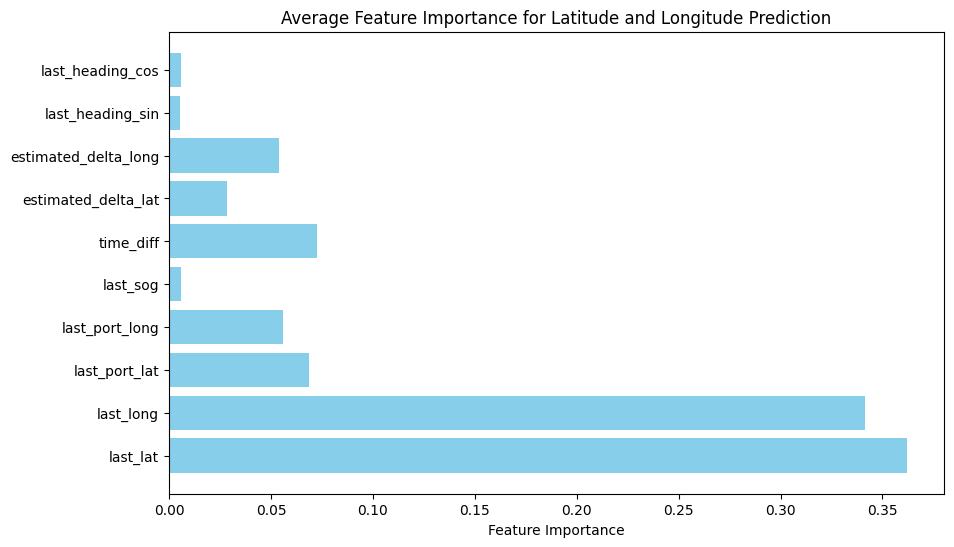

Results saved to submission_10.csv


In [11]:
features = [
       'last_lat', 'last_long', 'last_port_lat',
       'last_port_long', 'last_sog',
       'time_diff', 'estimated_delta_lat', 'estimated_delta_long', 
       'last_heading_sin', 'last_heading_cos']

predictors = ['latitude', 'longitude']

X_train = train_data[features]
y_train = train_data[predictors]
X_test = test_data[features]

RFR = RandomForestRegressor(n_estimators = 100, n_jobs = -1, random_state = 42, verbose = 2)
multi_output_regressor = MultiOutputRegressor(RFR)

multi_output_regressor.fit(X_train, y_train)

y_pred = multi_output_regressor.predict(X_test)

y_pred_lat = y_pred[:, 0]
y_pred_long = y_pred[:, 1]

# Extract feature importances for each target
latitude_importances = multi_output_regressor.estimators_[0].feature_importances_
longitude_importances = multi_output_regressor.estimators_[1].feature_importances_

# Average feature importances across targets for a combined importance
average_importances = np.mean([latitude_importances, longitude_importances], axis=0)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(features, average_importances, color="skyblue")
plt.xlabel("Feature Importance")
plt.title("Average Feature Importance for Latitude and Longitude Prediction")
plt.show()

submit(df_test['ID'], y_pred_long, y_pred_lat)

In [ ]:
print(pd.Series(y_pred_long).describe())
print(pd.Series(y_pred_lat).describe())